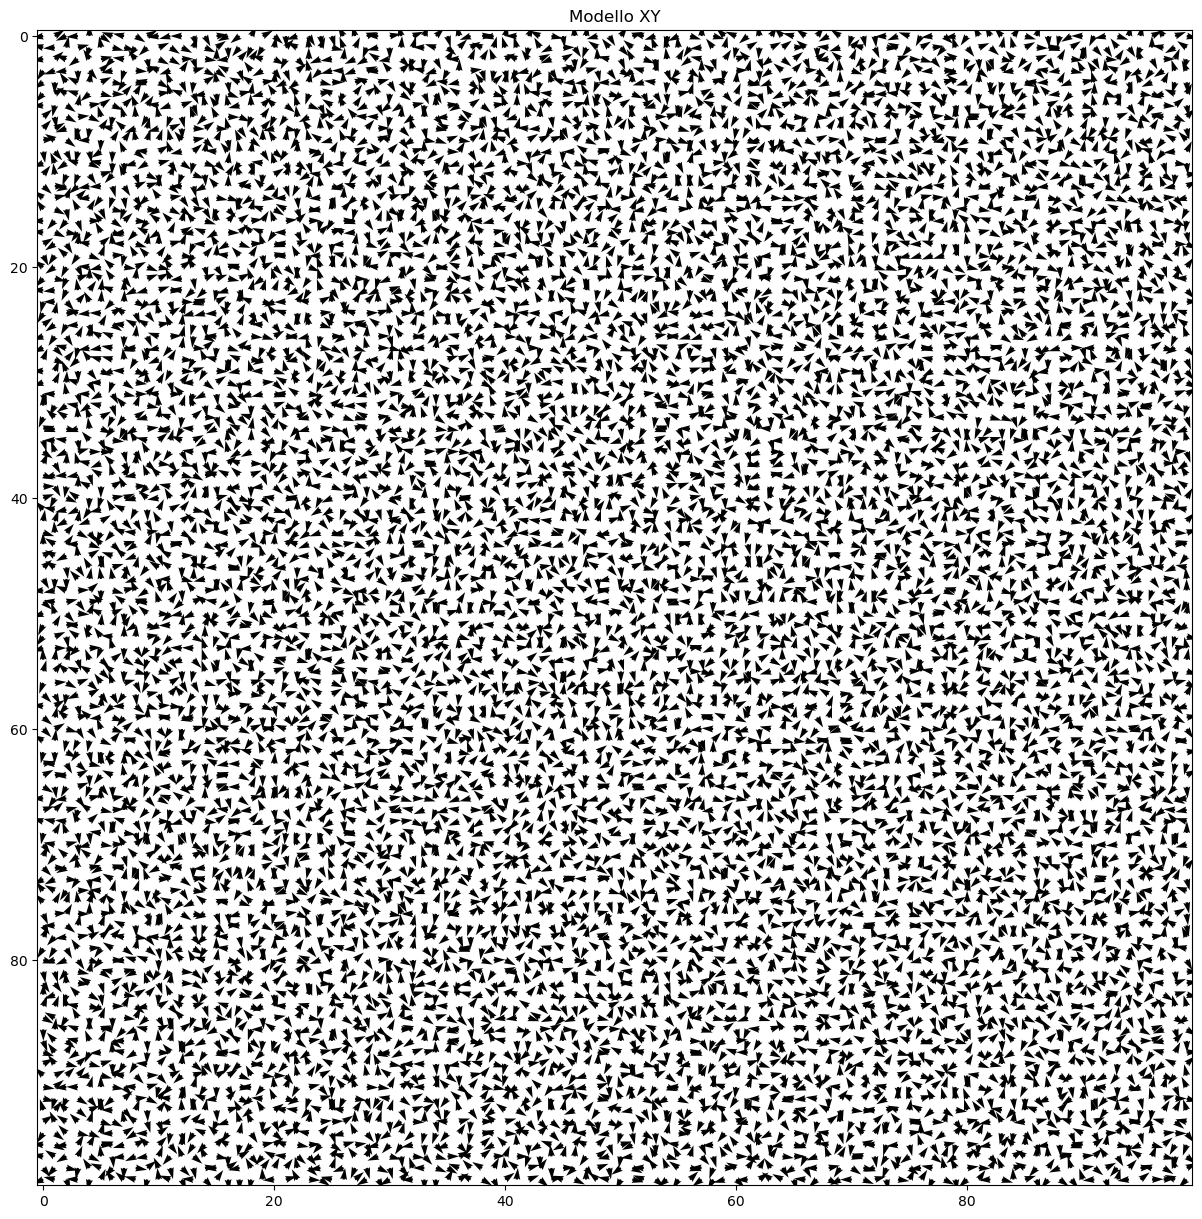

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time

#PARAMETRI
sqrtN=100
beta=1
Condizioni_al_bordo_periodiche = True

#GENERAZIONE MATRICE CASUALE
M = 2 * np.pi * np.random.random((sqrtN, sqrtN))

# componenti delle frecce
U = np.cos(M)
V = np.sin(M)

# coordinate della griglia
y, x = np.mgrid[0:M.shape[0], 0:M.shape[1]]

plt.figure(figsize=(15, 15))
plt.quiver(x, y, U, V, angles='xy', scale_units='xy', scale=1)
plt.xlim(-0.5, M.shape[1] - 0.5)
plt.ylim(-0.5, M.shape[0] - 0.5)
plt.gca().set_aspect('equal')
plt.gca().invert_yaxis()
plt.title("Modello XY")
plt.show()

In [2]:
#FUNZIONI
def vicini(M, will, rd):
    # padding di k zeri attorno alla matrice
    Mpad = np.pad(A, pad_width=rd, mode='constant', constant_values=0)
    # nuova posizione dell'elemento nella matrice padded
    i2 = will[0] + rd
    j2 = will[1] + rd
    #print('bbbbb')
    #print(Mpad)
    #print(Mpad[i2-rd:i2+rd+1, j2-rd:j2+rd+1])
    # estrai la finestra
    return Mpad[i2-rd:i2+rd+1, j2-rd:j2+rd+1]

In [3]:
#INTERAZIONE
raggio_pv=1

#FUNZIONI
def vicini(M, will, raggio_pv):
    Mpad = np.pad(M, pad_width=raggio_pv, mode='constant', constant_values=7)
    # nuova posizione dell'elemento nella matrice padded
    i2 = will[0] + raggio_pv
    j2 = will[1] + raggio_pv

    return Mpad[i2-rd:i2+rd+1, j2-rd:j2+rd+1]

def metrica(i,j):
    return np.sqrt(i**2 + j**2)

def Span(raggio_pv):
    lista=[]
    for i in range(-raggio_pv, raggio_pv + 1):
        for j in range(-raggio_pv, raggio_pv + 1):
            if metrica(i,j)<=raggio_pv and i!=j:
                lista.append((i,j,metrica(i,j)))
    return lista
Span=Span(raggio_pv)
print(Span)

[(-1, 0, 1.0), (0, -1, 1.0), (0, 1, 1.0), (1, 0, 1.0)]


In [4]:
#DINAMICA
def H_local(M,i,j):
    H=0
    for k in range(len(Span)):
                if (0<=i+Span[k][0]<sqrtN and 0<=j+Span[k][1]<sqrtN) or Condizioni_al_bordo_periodiche == True:
                    ni = (i+Span[k][0]) % sqrtN
                    nj = (j+Span[k][1]) % sqrtN
                    h_ijk=-np.cos(M[i,j]-M[ni, nj])  
                    H=H+h_ijk
    return H

def I_local(M,i,j):
    I=0
    for k in range(len(Span)):
                if (0<=i+Span[k][0]<sqrtN and 0<=j+Span[k][1]<sqrtN) or Condizioni_al_bordo_periodiche == True:
                    ni = (i+Span[k][0]) % sqrtN
                    nj = (j+Span[k][1]) % sqrtN
                    i_ijk=-np.sin(M[i,j]-M[ni, nj])  
                    I=I+i_ijk
    return I
    
def H(M):
    H=0
    for i in range(sqrtN):
        for j in range(sqrtN):
            H=H+H_local(M,i,j)
    return H

def I_(M):
    I=0
    for i in range(sqrtN):
        for j in range(sqrtN):
            I=I+I_local(M,i,j)
    return I


In [5]:
#VISUALIZZAZIONE
def diff_x_centered_periodic(M):
    return (np.roll(M, -1, axis=1) - np.roll(M, 1, axis=1)) / 2.0

def diff_y_centered_periodic(M):
    return (np.roll(M, -1, axis=0) - np.roll(M, 1, axis=0)) / 2.0

def ROT(M):
    dSy_dx=-diff_x_centered_periodic(np.sin(M))
    dSx_dy=-diff_y_centered_periodic(np.cos(M))
    rot = dSy_dx - dSx_dy
    return rot

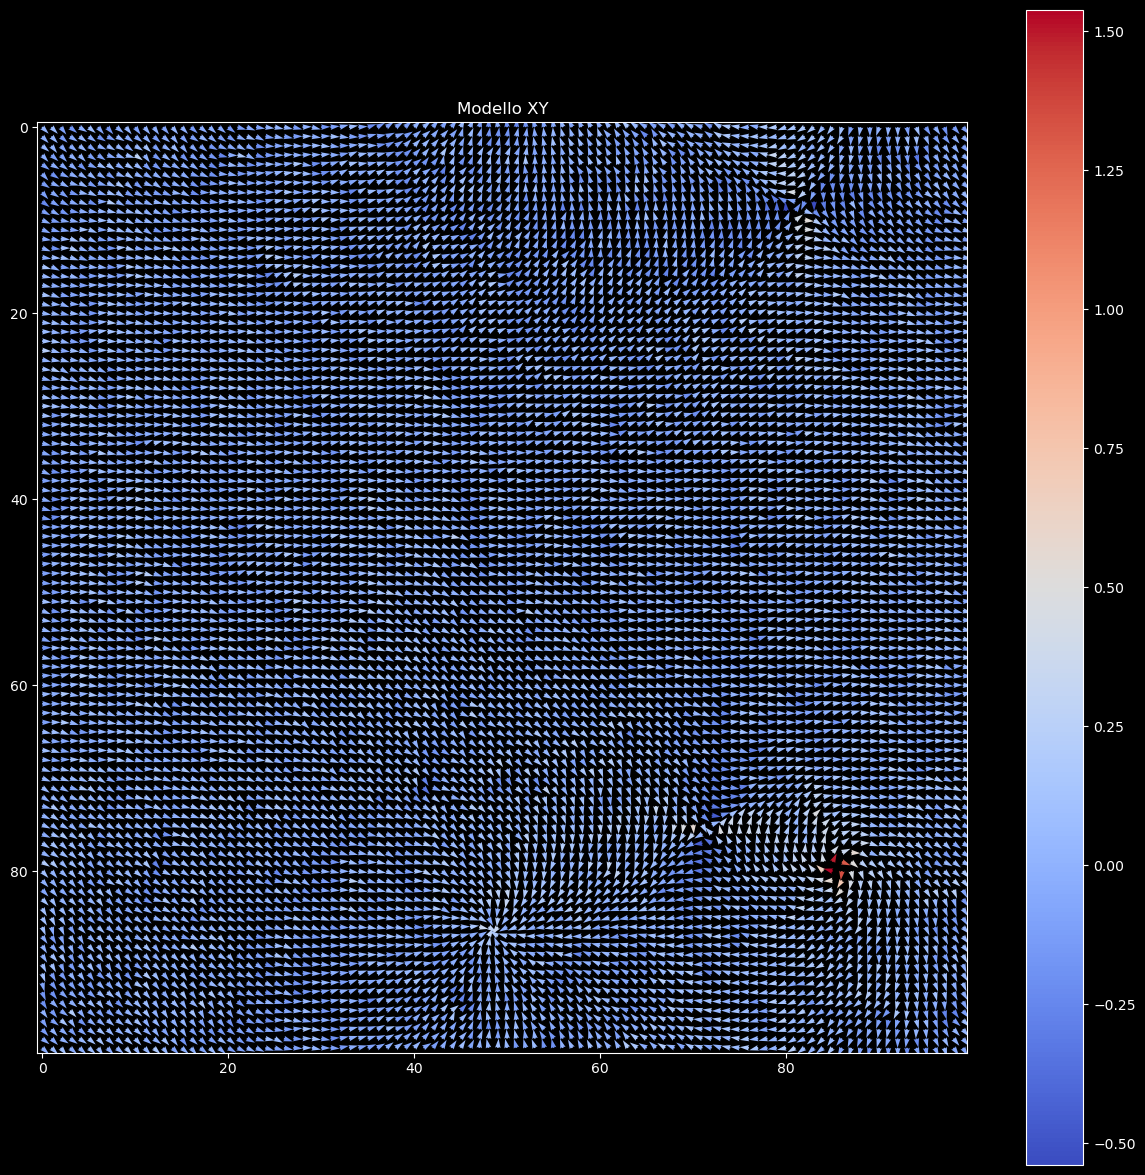

E = -19793.673610155573
I = 98908520.9203284
beta = 26.935000000009936


In [ ]:
#METROPOLIS
frame=0
E=H(M)
I=I_(M)
for _ in range(40000):
    y, x = np.mgrid[0:M.shape[0], 0:M.shape[1]]
    U = np.cos(M)
    V = np.sin(M)
    plt.figure(figsize=(15, 15))
    plt.style.use('dark_background')
    q = plt.quiver(x, y, U, V, ROT(M), cmap='coolwarm',angles='xy', scale_units='xy', scale=1)
    plt.colorbar(q)
    plt.xlim(-0.5, M.shape[1] - 0.5)
    plt.ylim(-0.5, M.shape[0] - 0.5)
    plt.gca().set_aspect('equal')
    plt.gca().invert_yaxis()
    plt.title("Modello XY")
    plt.show()
    print("E =", E)
    print("I =", I)
    beta=0.001+beta
    print("beta =", beta)
    
    a=0
    while a<1000:
        will=np.random.randint(0,sqrtN,size=2)
        WILL=np.zeros((sqrtN, sqrtN))
        WILL[will[0],will[1]]=1
        x = np.sqrt(np.pi)*np.random.normal()/2
        M_new=(M+x*WILL) % (2 * np.pi)
        delta_E=H_local(M_new, will[0], will[1])-H_local(M, will[0], will[1])
        if delta_E<=0 or np.random.random() < np.exp(-beta * delta_E):
            M=M_new
            E=E+delta_E
            a=a+1
            I=I+I_local(M_new, will[0], will[1])-H_local(M, will[0], will[1])
    clear_output(wait=True)
    #time.sleep(0.1)

In [ ]:
print(Span[1][0])